# Tiling and stitching segmentation outputs

* Author: Gonzalo Mateo-García

This tutorial shows how to run an AI model by fix-size tiles following the recommendations of *Huang et al. 2018*:

B. Huang, D. Reichman, L. M. Collins, K. Bradbury, and J. M. Malof, **Tiling and Stitching Segmentation Output for Remote Sensing: Basic Challenges and Recommendations**, [arXiv:1805.12219](http://arxiv.org/abs/1805.12219)

```
pip install cloudsen12_models georeader-spaceml fsspec gcsfs
```

In [1]:
# cloudsen12_models is not a georeader dependency (it depends on georeader),
# so install it in the running kernel.
%pip install cloudsen12_models






































































Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from georeader.readers import S2_SAFE_reader
from georeader import read
from shapely.geometry import box
from georeader import plot
from cloudsen12_models import cloudsen12
from georeader import slices
from rasterio import windows
from georeader.geotensor import GeoTensor
from georeader import window_utils
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

os.environ["GS_NO_SIGN_REQUEST"] = "YES"

## Load sample data

In [3]:
%%time

# Download a S2 product
safe_file = "S2A_MSIL1C_20240417T064631_N0510_R020_T40RCN_20240417T091941.SAFE"
s2_safe_folder = S2_SAFE_reader.s2_public_bucket_path(safe_file, check_exists=False)

print(f"File is located at: {s2_safe_folder}")

s2obj = S2_SAFE_reader.s2loader(s2_safe_folder, out_res=10)

tempfolder = "../../deleteme"
os.makedirs(tempfolder,exist_ok=True)
s2obj = s2obj.cache_product_to_local_dir(tempfolder)

s2obj

File is located at: gs://gcp-public-data-sentinel-2/tiles/40/R/CN/S2A_MSIL1C_20240417T064631_N0510_R020_T40RCN_20240417T091941.SAFE


Donwloading band B12 from gs://gcp-public-data-sentinel-2/tiles/40/R/CN/S2A_MSIL1C_20240417T064631_N0510_R020_T40RCN_20240417T091941.SAFE/GRANULE/L1C_T40RCN_A046063_20240417T070110/IMG_DATA/T40RCN_20240417T064631_B12.jp2 to ../../deleteme/S2A_MSIL1C_20240417T064631_N0510_R020_T40RCN_20240417T091941.SAFE/GRANULE/L1C_T40RCN_A046063_20240417T070110/IMG_DATA/T40RCN_20240417T064631_B12.jp2: 100%|██████████| 13/13 [00:23<00:00,  1.84s/it]


CPU times: user 2.96 s, sys: 1.77 s, total: 4.73 s
Wall time: 24.8 s


 
         ../../deleteme/S2A_MSIL1C_20240417T064631_N0510_R020_T40RCN_20240417T091941.SAFE
         Transform: | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 2800020.00|
| 0.00, 0.00, 1.00|
         Shape: (13, 10980, 10980)
         Resolution: (10.0, 10.0)
         Bounds: (300000.0, 2690220.0, 409800.0, 2800020.0)
         CRS: EPSG:32640
         bands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B10', 'B11', 'B12']
         fill_value_default: 0
        

In [4]:
%%time
aoi = box(55.325, 25.21, 55.515, 25.31)

data = read.read_from_polygon(s2obj, aoi, crs_polygon="EPSG:4326", trigger_load=True)
data

CPU times: user 13 s, sys: 610 ms, total: 13.6 s
Wall time: 5.84 s


 
         Transform: | 10.00, 0.00, 331240.00|
| 0.00,-10.00, 2800330.00|
| 0.00, 0.00, 1.00|
         Shape: (13, 1131, 1928)
         Resolution: (10.0, 10.0)
         Bounds: (331240.0, 2789020.0, 350520.0, 2800330.0)
         CRS: EPSG:32640
         fill_value_default: 0
        

## Load model

We will use the CloudSEN12 cloud detection model as sample.

In [5]:
model = cloudsen12.load_model_by_name(name="UNetMobV2_V2", 
                                      weights_folder="../../cloudsen12_models")

UNetMobV2_V2.pt: reconstructing file:   0%|          |  0.00B / 26.8MB            

UNetMobV2_V2.pt: downloading bytes:           |  0.00B            

## Tiling and stitching loop

In [6]:
overlap_total_pixels = 32 #  on each side!
window_size_predict_nn = 512

input_tensor = data

windows_write = slices.create_windows(input_tensor.shape[-2:], 
                                      window_size=(window_size_predict_nn-overlap_total_pixels, 
                                                   window_size_predict_nn-overlap_total_pixels), 
                                      overlap=(0, 0), 
                                      trim_incomplete=True)


output_tensor = GeoTensor(np.full(input_tensor.shape[-2:],fill_value=0,dtype=np.float32), 
                          transform=input_tensor.transform, 
                          crs=input_tensor.crs,
                          fill_value_default = 0)

for w_write in tqdm(windows_write):
    w_read = window_utils.pad_window_to_size(w_write, 
                                             size=(window_size_predict_nn, 
                                                   window_size_predict_nn))
    
    input_tensor_iter = read.read_from_window(input_tensor, 
                                              window=w_read, 
                                              boundless=True,
                                             trigger_load=True)
    valids_iter = np.all(input_tensor_iter.values != input_tensor_iter.fill_value_default, 
                         axis=0)
    
    if not np.any(valids_iter):
        # print("All invalid")
        continue

    slice_save = window_utils.slice_save_for_pred(w_read, w_write)
    
    out = model.predict(input_tensor_iter.values / 10_000)
    out[~valids_iter] = output_tensor.fill_value_default
    out_save = out[slice_save]
    
    output_tensor.write_from_window(out_save, window=w_write)

100%|██████████| 15/15 [00:03<00:00,  4.05it/s]


<Axes: >

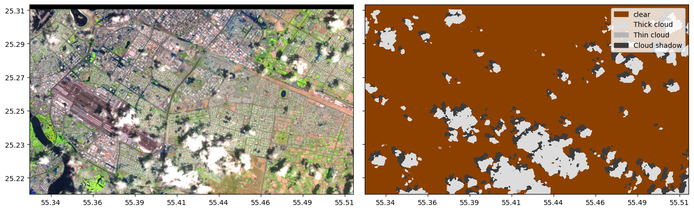

In [7]:
# For plotting
bands = s2obj.bands
swirnirred = (data.isel({"band": [bands.index(b) for b in ["B11","B08","B04"]]}) / 4_500.).clip(0,1)

fig, ax = plt.subplots(1,2,figsize=(14,5),sharey=True, tight_layout=True)
plot.show(swirnirred,ax=ax[0])
cloudsen12.plot_cloudSEN12mask(output_tensor,ax=ax[1])

## Async fan-out — swap the read loop

The loop above reads one padded window per tile, sequentially. For workloads
where the tiles come from cloud storage and the reads are network-bound (a
tile server, an async ML inference service), swap the per-tile read for
`AsyncGeoTIFFReader` + `asyncio.gather`: all window reads go out
concurrently, and the model inference itself stays sync — only the reads
parallelise.

The cell below demonstrates on a small subsample — the first four tiles of
the loop above: it saves the AOI crop as a local COG, opens it with
`AsyncGeoTIFFReader` over a `LocalStore`, gathers the four padded window
reads at once, then runs the (sync) model per chip and stitches exactly as
before — and checks the result matches the sync loop on those tiles.
Against a cloud bucket the code is identical: swap `LocalStore` for
`S3Store` / `GCSStore` / `AzureStore`.

See [`async_geotiff_reader.ipynb`](async_geotiff_reader.ipynb) for the full
tutorial — when to use which reader, the two-phase laziness model, gotchas,
and a mini-solution for post-load warp/reproject.


In [8]:
import asyncio

from obstore.store import LocalStore
from georeader.async_geotiff_reader import AsyncGeoTIFFReader
from georeader.save import save_cog

# The async reader reads files/objects, not in-memory tensors — persist the
# AOI crop as a COG first (in the same scratch folder as the SAFE cache).
cog_path = os.path.join(tempfolder, "tiling_async_demo.tif")
save_cog(input_tensor, cog_path)

async_store = LocalStore(prefix=os.path.dirname(os.path.abspath(cog_path)))
async_reader = await AsyncGeoTIFFReader.open(os.path.basename(cog_path), store=async_store)

# Demo subsample: the first four tiles of the loop above. In a real service
# you would gather the full windows_write list.
windows_write_demo = windows_write[:4]
windows_read_demo = [
    window_utils.pad_window_to_size(w, size=(window_size_predict_nn, window_size_predict_nn))
    for w in windows_write_demo
]

# Fan out the padded window reads concurrently (the sync loop reads them
# one at a time).
chips = await asyncio.gather(
    *[async_reader.read_from_window(w, boundless=True).load() for w in windows_read_demo]
)

# Model + stitch stay sync — identical to the loop above.
for w_write, w_read, chip in zip(windows_write_demo, windows_read_demo, chips):
    valids_iter = np.all(chip.values != chip.fill_value_default, axis=0)
    if not np.any(valids_iter):
        continue
    slice_save = window_utils.slice_save_for_pred(w_read, w_write)
    out = model.predict(chip.values / 10_000)
    out[~valids_iter] = output_tensor.fill_value_default
    out_save = out[slice_save]

    # Same tile, same pixels: the async-read chip yields the same prediction
    # the sync loop wrote into output_tensor.
    sync_tile = output_tensor.read_from_window(w_write, boundless=False).values
    assert np.allclose(out_save, sync_tile), "async-read tile diverged from the sync loop"

print(f"{len(chips)} tiles read concurrently; predictions match the sync loop")


4 tiles read concurrently; predictions match the sync loop


## Licence
This notebook is released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt).

The `cloudsen12_models` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *CloudSEN12* database and all pre-trained models are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt). For using the models in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:
```
@article{aybar_cloudsen12_2024,
	title = {{CloudSEN12}+: {The} largest dataset of expert-labeled pixels for cloud and cloud shadow detection in {Sentinel}-2},
	issn = {2352-3409},
	url = {https://www.sciencedirect.com/science/article/pii/S2352340924008163},
	doi = {10.1016/j.dib.2024.110852},
	journal = {Data in Brief},
	author = {Aybar, Cesar and Bautista, Lesly and Montero, David and Contreras, Julio and Ayala, Daryl and Prudencio, Fernando and Loja, Jhomira and Ysuhuaylas, Luis and Herrera, Fernando and Gonzales, Karen and Valladares, Jeanett and Flores, Lucy A. and Mamani, Evelin and Quiñonez, Maria and Fajardo, Rai and Espinoza, Wendy and Limas, Antonio and Yali, Roy and Alcántara, Alejandro and Leyva, Martin and Loayza-Muro, Rau´l and Willems, Bram and Mateo-García, Gonzalo and Gómez-Chova, Luis},
	month = aug,
	year = {2024},
	pages = {110852},
}
```